In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

Using device: cuda


## 1. Load Data

In [2]:
# Load all data sources
drug_effects = pd.read_pickle('drug_clinical_effects.pkl')
drug_nodes = pd.read_pickle('approved_small_molecule_drugs.pkl')
drugs_interactions = pd.read_pickle('drug_protein_interactions.pkl')
protein_nodes = pd.read_pickle('protein_nodes_with_embeddings_extended.pkl')
drug_therapeutic_classes = pd.read_pickle('drug_therapeutic_classes_atc.pkl')
mechanism_of_action = pd.read_pickle('drug_mechanism_of_action.pkl')
drug_warnings = pd.read_pickle('drug_warnings_adverse_effects.pkl')

print("Data loaded:")
print(f"  Drugs: {len(drug_nodes)}")
print(f"  Proteins: {len(protein_nodes)}")
print(f"  Drug-Effects: {len(drug_effects)}")
print(f"  Drug-Protein Interactions: {len(drugs_interactions)}")
print(f"  Therapeutic Classes: {len(drug_therapeutic_classes)}")
print(f"  Mechanism of Action: {len(mechanism_of_action)}")
print(f"  Drug Warnings: {len(drug_warnings)}")

Data loaded:
  Drugs: 1915414
  Proteins: 4040
  Drug-Effects: 59954
  Drug-Protein Interactions: 1783205
  Therapeutic Classes: 4569
  Mechanism of Action: 7256
  Drug Warnings: 2302


## 2. Build Entity Indices (Embedding Lookup Tables)

In [3]:
# Build entity-to-index mappings for each entity type

# DRUGS - use drug_internal_id
drug_to_idx = {int(row['drug_internal_id']): i for i, row in drug_nodes.iterrows()}
idx_to_drug = {i: int(row['drug_internal_id']) for i, row in drug_nodes.iterrows()}
num_drugs = len(drug_to_idx)

# PROTEINS - use protein_internal_id
protein_to_idx = {int(row['protein_internal_id']): i for i, row in protein_nodes.iterrows()}
idx_to_protein = {i: int(row['protein_internal_id']) for i, row in protein_nodes.iterrows()}
num_proteins = len(protein_to_idx)

# EFFECTS - use effect_id
unique_effects = drug_effects[['effect_id', 'effect_name']].drop_duplicates()
effect_to_idx = {str(row['effect_id']): i for i, (_, row) in enumerate(unique_effects.iterrows())}
idx_to_effect = {i: str(row['effect_id']) for i, (_, row) in enumerate(unique_effects.iterrows())}
num_effects = len(effect_to_idx)

# TARGETS - from mechanism_of_action (filter NaN)
target_data = mechanism_of_action[mechanism_of_action['target_internal_id'].notna()][['target_internal_id', 'target_name']].drop_duplicates()
target_to_idx = {int(row['target_internal_id']): i for i, (_, row) in enumerate(target_data.iterrows())}
idx_to_target = {i: int(row['target_internal_id']) for i, (_, row) in enumerate(target_data.iterrows())}
num_targets = len(target_to_idx)

# WARNINGS - use warning_description
valid_warnings = drug_warnings[drug_warnings['warning_description'].notna()]['warning_description'].unique()
warning_to_idx = {str(desc): i for i, desc in enumerate(valid_warnings)}
idx_to_warning = {i: str(desc) for i, desc in enumerate(valid_warnings)}
num_warnings = len(warning_to_idx)

# THERAPEUTIC CLASSES (Level 4 only for simplicity)
level4_descriptions = drug_therapeutic_classes['level4_description'].unique()
therapeutic_to_idx = {str(desc): i for i, desc in enumerate(level4_descriptions)}
idx_to_therapeutic = {i: str(desc) for i, desc in enumerate(level4_descriptions)}
num_therapeutics = len(therapeutic_to_idx)

print("\n" + "="*60)
print("ENTITY COUNTS (Embedding Lookup Tables)")
print("="*60)
print(f"  Drugs:       {num_drugs:,}")
print(f"  Proteins:    {num_proteins:,}")
print(f"  Effects:     {num_effects:,}")
print(f"  Targets:     {num_targets:,}")
print(f"  Warnings:    {num_warnings:,}")
print(f"  Therapeutics (L4): {num_therapeutics:,}")
print(f"  TOTAL:       {num_drugs + num_proteins + num_effects + num_targets + num_warnings + num_therapeutics:,}")


ENTITY COUNTS (Embedding Lookup Tables)
  Drugs:       1,915,414
  Proteins:    4,040
  Effects:     2,178
  Targets:     1,518
  Warnings:    462
  Therapeutics (L4): 666
  TOTAL:       1,924,278


## 3. Build Knowledge Graph Edges (Triplets)

In [4]:
# Define relation types
RELATIONS = {
    'drug_binds_protein': 0,
    'drug_causes_effect': 1,
    'drug_acts_on_target': 2,
    'drug_has_warning': 3,
    'drug_has_therapeutic': 4,
}
num_relations = len(RELATIONS)

# Build triplets: (head_type, head_idx, relation, tail_type, tail_idx)
triplets = []

# 1. Drug-Protein interactions
print("Building Drug-Protein triplets...")
for _, row in tqdm(drugs_interactions.iterrows(), total=len(drugs_interactions)):
    drug_id = int(row['drug_internal_id'])
    protein_id = int(row['protein_internal_id'])
    
    if drug_id in drug_to_idx and protein_id in protein_to_idx:
        triplets.append(('drug', drug_to_idx[drug_id], RELATIONS['drug_binds_protein'], 'protein', protein_to_idx[protein_id]))

# 2. Drug-Effect
print("Building Drug-Effect triplets...")
for _, row in tqdm(drug_effects.iterrows(), total=len(drug_effects)):
    drug_id = int(row['drug_internal_id'])
    effect_id = str(row['effect_id'])
    
    if drug_id in drug_to_idx and effect_id in effect_to_idx:
        triplets.append(('drug', drug_to_idx[drug_id], RELATIONS['drug_causes_effect'], 'effect', effect_to_idx[effect_id]))

# 3. Drug-Target (Mechanism of Action)
print("Building Drug-Target triplets...")
valid_moa = mechanism_of_action[
    (mechanism_of_action['drug_internal_id'].notna()) & 
    (mechanism_of_action['target_internal_id'].notna())
]
for _, row in tqdm(valid_moa.iterrows(), total=len(valid_moa)):
    drug_id = int(row['drug_internal_id'])
    target_id = int(row['target_internal_id'])
    
    if drug_id in drug_to_idx and target_id in target_to_idx:
        triplets.append(('drug', drug_to_idx[drug_id], RELATIONS['drug_acts_on_target'], 'target', target_to_idx[target_id]))

# 4. Drug-Warning
print("Building Drug-Warning triplets...")
valid_warn = drug_warnings[
    (drug_warnings['drug_internal_id'].notna()) & 
    (drug_warnings['warning_description'].notna())
]
for _, row in tqdm(valid_warn.iterrows(), total=len(valid_warn)):
    drug_id = int(row['drug_internal_id'])
    warning_desc = str(row['warning_description'])
    
    if drug_id in drug_to_idx and warning_desc in warning_to_idx:
        triplets.append(('drug', drug_to_idx[drug_id], RELATIONS['drug_has_warning'], 'warning', warning_to_idx[warning_desc]))

# 5. Drug-Therapeutic Class
print("Building Drug-Therapeutic triplets...")
for _, row in tqdm(drug_therapeutic_classes.iterrows(), total=len(drug_therapeutic_classes)):
    drug_id = int(row['drug_internal_id'])
    therapeutic_desc = str(row['level4_description'])
    
    if drug_id in drug_to_idx and therapeutic_desc in therapeutic_to_idx:
        triplets.append(('drug', drug_to_idx[drug_id], RELATIONS['drug_has_therapeutic'], 'therapeutic', therapeutic_to_idx[therapeutic_desc]))

# Remove duplicates
triplets = list(set(triplets))

print(f"\n" + "="*60)
print("TRIPLET STATISTICS")
print("="*60)
relation_counts = {}
for t in triplets:
    rel = t[2]
    relation_counts[rel] = relation_counts.get(rel, 0) + 1

for rel_name, rel_idx in RELATIONS.items():
    count = relation_counts.get(rel_idx, 0)
    print(f"  {rel_name}: {count:,}")
print(f"  TOTAL: {len(triplets):,}")

Building Drug-Protein triplets...


100%|██████████| 1783205/1783205 [00:14<00:00, 124401.61it/s]


Building Drug-Effect triplets...


100%|██████████| 59954/59954 [00:00<00:00, 109930.86it/s]


Building Drug-Target triplets...


...

Building Drug-Warning triplets...


100%|██████████| 1012/1012 [00:00<00:00, 109431.67it/s]


Building Drug-Therapeutic triplets...


100%|██████████| 4569/4569 [00:00<00:00, 108767.05it/s]



TRIPLET STATISTICS
  drug_binds_protein: 961,097
  drug_causes_effect: 40,090
  drug_acts_on_target: 4,890
  drug_has_therapeutic: 3,404
  TOTAL: 1,009,995


## 4. TransR Model with Embedding Lookup

In [5]:
class TransRKnowledgeGraph(nn.Module):
    """
    Pure TransR Knowledge Graph Embedding Model.
    
    Uses simple embedding lookup for all entities (no features).
    TransR projects entities to relation-specific spaces for scoring.
    
    Score(h, r, t) = -||M_r * h + r - M_r * t||_2
    """
    
    def __init__(self, entity_counts, num_relations, entity_dim=128, relation_dim=64, margin=1.0):
        super().__init__()
        
        self.entity_dim = entity_dim
        self.relation_dim = relation_dim
        self.margin = margin
        self.entity_counts = entity_counts
        
        # Entity embeddings (simple lookup) - one embedding table per entity type
        self.entity_embeddings = nn.ModuleDict({
            entity_type: nn.Embedding(count, entity_dim)
            for entity_type, count in entity_counts.items()
        })
        
        # Relation embeddings
        self.relation_embeddings = nn.Embedding(num_relations, relation_dim)
        
        # TransR projection matrices: project from entity_dim to relation_dim
        # M_r ∈ R^{relation_dim x entity_dim}
        self.projection_matrices = nn.Parameter(
            torch.zeros(num_relations, relation_dim, entity_dim)
        )
        
        # Initialize
        self._init_embeddings()
        
    def _init_embeddings(self):
        """Initialize embeddings with uniform distribution"""
        for emb in self.entity_embeddings.values():
            nn.init.uniform_(emb.weight, -6/np.sqrt(self.entity_dim), 6/np.sqrt(self.entity_dim))
            # Normalize
            emb.weight.data = F.normalize(emb.weight.data, p=2, dim=1)
        
        nn.init.uniform_(self.relation_embeddings.weight, -6/np.sqrt(self.relation_dim), 6/np.sqrt(self.relation_dim))
        # Normalize
        self.relation_embeddings.weight.data = F.normalize(self.relation_embeddings.weight.data, p=2, dim=1)
        
        # Initialize projection matrices as identity-like
        nn.init.eye_(self.projection_matrices.view(-1, self.relation_dim, self.entity_dim)[0])
        for i in range(1, self.projection_matrices.size(0)):
            nn.init.eye_(self.projection_matrices[i])
    
    def get_entity_embedding(self, entity_type, entity_idx):
        """Get embedding for entity by type and index"""
        return self.entity_embeddings[entity_type](entity_idx)
    
    def project_to_relation_space(self, entity_emb, relation_idx):
        """
        Project entity to relation-specific space.
        projected = M_r @ entity
        """
        # entity_emb: (batch, entity_dim)
        # M_r: (relation_dim, entity_dim)
        M_r = self.projection_matrices[relation_idx]  # (relation_dim, entity_dim)
        projected = torch.matmul(entity_emb, M_r.T)  # (batch, relation_dim)
        return F.normalize(projected, p=2, dim=-1)
    
    def score_triplet(self, head_type, head_idx, relation_idx, tail_type, tail_idx):
        """
        TransR scoring function.
        Score = -||M_r * h + r - M_r * t||_2
        """
        # Get entity embeddings
        h = self.get_entity_embedding(head_type, head_idx)  # (batch, entity_dim)
        t = self.get_entity_embedding(tail_type, tail_idx)  # (batch, entity_dim)
        
        # Project to relation space
        h_r = self.project_to_relation_space(h, relation_idx)  # (batch, relation_dim)
        t_r = self.project_to_relation_space(t, relation_idx)  # (batch, relation_dim)
        
        # Get relation vector
        r = self.relation_embeddings(torch.tensor([relation_idx], device=h.device))  # (1, relation_dim)
        
        # Compute distance: ||h_r + r - t_r||_2
        diff = h_r + r - t_r
        distance = torch.norm(diff, p=2, dim=-1)  # (batch,)
        
        return distance
    
    def forward(self, pos_triplets, neg_triplets):
        """
        Compute margin-based ranking loss.
        Loss = max(0, margin + pos_score - neg_score)
        
        pos_triplets: list of (head_type, head_idx, rel_idx, tail_type, tail_idx)
        neg_triplets: list of (head_type, head_idx, rel_idx, tail_type, tail_idx)
        """
        pos_scores = []
        neg_scores = []
        
        for pos, neg in zip(pos_triplets, neg_triplets):
            pos_score = self.score_triplet(
                pos[0], torch.tensor([pos[1]], device=next(self.parameters()).device),
                pos[2],
                pos[3], torch.tensor([pos[4]], device=next(self.parameters()).device)
            )
            neg_score = self.score_triplet(
                neg[0], torch.tensor([neg[1]], device=next(self.parameters()).device),
                neg[2],
                neg[3], torch.tensor([neg[4]], device=next(self.parameters()).device)
            )
            pos_scores.append(pos_score)
            neg_scores.append(neg_score)
        
        pos_scores = torch.cat(pos_scores)
        neg_scores = torch.cat(neg_scores)
        
        # Margin ranking loss (positive should have SMALLER distance)
        loss = F.relu(self.margin + pos_scores - neg_scores).mean()
        
        return loss
    
    def predict(self, head_type, head_idx, relation_idx, tail_type, tail_idx):
        """Predict probability of triplet being true (lower distance = higher prob)"""
        distance = self.score_triplet(head_type, head_idx, relation_idx, tail_type, tail_idx)
        # Convert distance to probability (sigmoid-based)
        prob = torch.sigmoid(self.margin - distance)
        return prob


# Initialize model
entity_counts = {
    'drug': num_drugs,
    'protein': num_proteins,
    'effect': num_effects,
    'target': num_targets,
    'warning': num_warnings,
    'therapeutic': num_therapeutics,
}

ENTITY_DIM = 128  # Embedding dimension for all entities
RELATION_DIM = 64  # Relation space dimension
MARGIN = 1.0

model = TransRKnowledgeGraph(
    entity_counts=entity_counts,
    num_relations=num_relations,
    entity_dim=ENTITY_DIM,
    relation_dim=RELATION_DIM,
    margin=MARGIN
).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
print(f"\n" + "="*60)
print("MODEL SUMMARY")
print("="*60)
print(f"  Entity dimension: {ENTITY_DIM}")
print(f"  Relation dimension: {RELATION_DIM}")
print(f"  Margin: {MARGIN}")
print(f"  Total parameters: {total_params:,}")
print(f"  Memory: {total_params * 4 / 1e6:.2f} MB")


MODEL SUMMARY
  Entity dimension: 128
  Relation dimension: 64
  Margin: 1.0
  Total parameters: 246,348,864
  Memory: 985.40 MB


## 5. Dataset and DataLoader

In [6]:
class KGTripletDataset(Dataset):
    """
    Dataset for Knowledge Graph triplets.
    Returns positive triplets and generates negative samples on-the-fly.
    """
    
    def __init__(self, triplets, entity_counts, neg_samples=1):
        self.triplets = triplets
        self.entity_counts = entity_counts
        self.neg_samples = neg_samples
        
        # Build set of positive triplets for filtering
        self.positive_set = set(triplets)
        
    def __len__(self):
        return len(self.triplets)
    
    def corrupt_triplet(self, triplet):
        """
        Generate negative sample by corrupting head or tail.
        """
        head_type, head_idx, rel, tail_type, tail_idx = triplet
        
        # Randomly corrupt head or tail
        if np.random.random() < 0.5:
            # Corrupt head
            new_head = np.random.randint(0, self.entity_counts[head_type])
            neg_triplet = (head_type, new_head, rel, tail_type, tail_idx)
        else:
            # Corrupt tail
            new_tail = np.random.randint(0, self.entity_counts[tail_type])
            neg_triplet = (head_type, head_idx, rel, tail_type, new_tail)
        
        # Make sure negative is not actually a positive
        max_tries = 10
        tries = 0
        while neg_triplet in self.positive_set and tries < max_tries:
            if np.random.random() < 0.5:
                new_head = np.random.randint(0, self.entity_counts[head_type])
                neg_triplet = (head_type, new_head, rel, tail_type, tail_idx)
            else:
                new_tail = np.random.randint(0, self.entity_counts[tail_type])
                neg_triplet = (head_type, head_idx, rel, tail_type, new_tail)
            tries += 1
        
        return neg_triplet
    
    def __getitem__(self, idx):
        pos_triplet = self.triplets[idx]
        neg_triplet = self.corrupt_triplet(pos_triplet)
        return pos_triplet, neg_triplet


def collate_triplets(batch):
    """Custom collate function for triplet batches"""
    pos_triplets = [item[0] for item in batch]
    neg_triplets = [item[1] for item in batch]
    return pos_triplets, neg_triplets


# Split data
np.random.seed(42)
indices = np.random.permutation(len(triplets))
train_size = int(0.8 * len(triplets))
val_size = int(0.1 * len(triplets))

train_triplets = [triplets[i] for i in indices[:train_size]]
val_triplets = [triplets[i] for i in indices[train_size:train_size+val_size]]
test_triplets = [triplets[i] for i in indices[train_size+val_size:]]

print(f"\nData split:")
print(f"  Train: {len(train_triplets):,}")
print(f"  Val:   {len(val_triplets):,}")
print(f"  Test:  {len(test_triplets):,}")

# Create datasets and dataloaders
train_dataset = KGTripletDataset(train_triplets, entity_counts)
val_dataset = KGTripletDataset(val_triplets, entity_counts)
test_dataset = KGTripletDataset(test_triplets, entity_counts)

BATCH_SIZE = 256

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_triplets, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_triplets, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_triplets, num_workers=0)


Data split:
  Train: 807,996
  Val:   100,999
  Test:  101,000


## 6. Training Loop

In [7]:
def train_epoch(model, train_loader, optimizer, device):
    model.train()
    total_loss = 0
    
    for pos_batch, neg_batch in tqdm(train_loader, desc="Training"):
        optimizer.zero_grad()
        
        loss = model(pos_batch, neg_batch)
        loss.backward()
        
        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        
        # Normalize embeddings after update (important for TransR)
        with torch.no_grad():
            for emb in model.entity_embeddings.values():
                emb.weight.data = F.normalize(emb.weight.data, p=2, dim=1)
            model.relation_embeddings.weight.data = F.normalize(model.relation_embeddings.weight.data, p=2, dim=1)
        
        total_loss += loss.item()
    
    return total_loss / len(train_loader)


def evaluate(model, data_loader, device):
    model.eval()
    total_loss = 0
    
    with torch.no_grad():
        for pos_batch, neg_batch in data_loader:
            loss = model(pos_batch, neg_batch)
            total_loss += loss.item()
    
    return total_loss / len(data_loader)


# Training
EPOCHS = 50
LR = 0.001

optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=5, factor=0.5)

best_val_loss = float('inf')
history = {'train_loss': [], 'val_loss': []}

print("\n" + "="*60)
print("TRAINING")
print("="*60)

for epoch in range(EPOCHS):
    train_loss = train_epoch(model, train_loader, optimizer, DEVICE)
    val_loss = evaluate(model, val_loader, DEVICE)
    
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    
    scheduler.step(val_loss)
    
    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'transr_knowledge_embeddings_best.pt')
    
    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | LR: {optimizer.param_groups[0]['lr']:.6f}")


TRAINING


Training: 100%|██████████| 3157/3157 [1:23:19<00:00,  1.58s/it]


Epoch 1/50 | Train Loss: 0.6213 | Val Loss: 0.5571 | LR: 0.001000


Training: 100%|██████████| 3157/3157 [1:23:02<00:00,  1.58s/it]


Epoch 2/50 | Train Loss: 0.4473 | Val Loss: 0.4769 | LR: 0.001000


Training: 100%|██████████| 3157/3157 [1:23:14<00:00,  1.58s/it]


Epoch 3/50 | Train Loss: 0.2889 | Val Loss: 0.4577 | LR: 0.001000


Training:   0%|          | 8/3157 [00:14<1:33:39,  1.78s/it]


KeyboardInterrupt: 

## 7. Evaluation Metrics

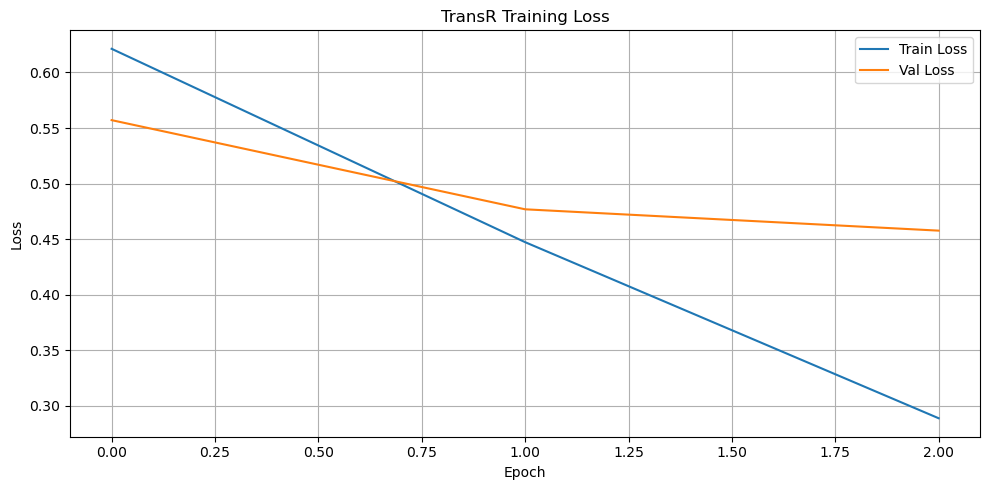

In [8]:
import matplotlib.pyplot as plt

# Plot training history
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(history['train_loss'], label='Train Loss')
ax.plot(history['val_loss'], label='Val Loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('TransR Training Loss')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.savefig('transr_training_loss.png', dpi=150)
plt.show()

In [9]:
def compute_metrics(model, test_triplets, entity_counts, device, sample_size=1000):
    """
    Compute link prediction metrics: Mean Rank, MRR, Hits@k
    """
    model.eval()
    
    # Sample for efficiency
    if len(test_triplets) > sample_size:
        sample_indices = np.random.choice(len(test_triplets), sample_size, replace=False)
        sampled_triplets = [test_triplets[i] for i in sample_indices]
    else:
        sampled_triplets = test_triplets
    
    ranks = []
    hits_at_1 = 0
    hits_at_3 = 0
    hits_at_10 = 0
    
    with torch.no_grad():
        for triplet in tqdm(sampled_triplets, desc="Computing metrics"):
            head_type, head_idx, rel, tail_type, tail_idx = triplet
            
            # Get true tail score
            true_score = model.score_triplet(
                head_type, torch.tensor([head_idx], device=device),
                rel,
                tail_type, torch.tensor([tail_idx], device=device)
            ).item()
            
            # Compare against all possible tails (sample for efficiency)
            num_candidates = min(100, entity_counts[tail_type])
            candidate_tails = np.random.choice(entity_counts[tail_type], num_candidates, replace=False)
            
            candidate_scores = []
            for cand_tail in candidate_tails:
                score = model.score_triplet(
                    head_type, torch.tensor([head_idx], device=device),
                    rel,
                    tail_type, torch.tensor([cand_tail], device=device)
                ).item()
                candidate_scores.append(score)
            
            # Rank (lower distance is better)
            rank = sum(1 for s in candidate_scores if s < true_score) + 1
            ranks.append(rank)
            
            if rank <= 1:
                hits_at_1 += 1
            if rank <= 3:
                hits_at_3 += 1
            if rank <= 10:
                hits_at_10 += 1
    
    n = len(sampled_triplets)
    mean_rank = np.mean(ranks)
    mrr = np.mean([1.0/r for r in ranks])
    
    print("\n" + "="*60)
    print("EVALUATION METRICS")
    print("="*60)
    print(f"  Mean Rank:  {mean_rank:.2f}")
    print(f"  MRR:        {mrr:.4f}")
    print(f"  Hits@1:     {hits_at_1/n*100:.2f}%")
    print(f"  Hits@3:     {hits_at_3/n*100:.2f}%")
    print(f"  Hits@10:    {hits_at_10/n*100:.2f}%")
    
    return {
        'mean_rank': mean_rank,
        'mrr': mrr,
        'hits_at_1': hits_at_1/n,
        'hits_at_3': hits_at_3/n,
        'hits_at_10': hits_at_10/n
    }

# Load best model and evaluate
model.load_state_dict(torch.load('transr_knowledge_embeddings_best.pt'))
metrics = compute_metrics(model, test_triplets, entity_counts, DEVICE)

Computing metrics: 100%|██████████| 1000/1000 [00:11<00:00, 85.37it/s]


EVALUATION METRICS
  Mean Rank:  8.15
  MRR:        0.4138
  Hits@1:     25.60%
  Hits@3:     47.80%
  Hits@10:    75.20%


## 8. Extract and Save Embeddings

In [10]:
# Extract all embeddings
model.eval()

embeddings = {}
with torch.no_grad():
    for entity_type, emb_layer in model.entity_embeddings.items():
        embeddings[entity_type] = emb_layer.weight.cpu().numpy()
        print(f"  {entity_type}: {embeddings[entity_type].shape}")

# Save embeddings
np.savez('transr_entity_embeddings.npz', **embeddings)
print("\n✓ Saved entity embeddings to transr_entity_embeddings.npz")

# Save relation embeddings and projection matrices
relation_data = {
    'relation_embeddings': model.relation_embeddings.weight.detach().cpu().numpy(),
    'projection_matrices': model.projection_matrices.detach().cpu().numpy()
}
np.savez('transr_relation_data.npz', **relation_data)
print("✓ Saved relation data to transr_relation_data.npz")

  drug: (1915414, 128)
  protein: (4040, 128)
  effect: (2178, 128)
  target: (1518, 128)
  therapeutic: (666, 128)

✓ Saved entity embeddings to transr_entity_embeddings.npz
✓ Saved relation data to transr_relation_data.npz


## 9. Link Prediction Example

In [11]:
def predict_tails(model, head_type, head_idx, relation_name, tail_type, entity_counts, top_k=10):
    """
    Predict most likely tail entities for a given head and relation.
    """
    model.eval()
    device = next(model.parameters()).device
    
    relation_idx = RELATIONS[relation_name]
    
    scores = []
    with torch.no_grad():
        for tail_idx in range(entity_counts[tail_type]):
            distance = model.score_triplet(
                head_type, torch.tensor([head_idx], device=device),
                relation_idx,
                tail_type, torch.tensor([tail_idx], device=device)
            ).item()
            scores.append((tail_idx, distance))
    
    # Sort by distance (lower is better)
    scores.sort(key=lambda x: x[1])
    
    return scores[:top_k]


# Example: Predict proteins that a drug might bind to
example_drug_idx = 0  # First drug
predictions = predict_tails(model, 'drug', example_drug_idx, 'drug_binds_protein', 'protein', entity_counts, top_k=10)

print("\n" + "="*60)
print(f"PREDICTION: Top 10 proteins for drug index {example_drug_idx}")
print("="*60)
for rank, (protein_idx, score) in enumerate(predictions, 1):
    print(f"  {rank}. Protein {protein_idx} (distance: {score:.4f})")


PREDICTION: Top 10 proteins for drug index 0
  1. Protein 1122 (distance: 0.3073)
  2. Protein 686 (distance: 0.3223)
  3. Protein 1766 (distance: 0.3379)
  4. Protein 86 (distance: 0.3789)
  5. Protein 346 (distance: 0.3891)
  6. Protein 651 (distance: 0.3897)
  7. Protein 722 (distance: 0.3917)
  8. Protein 179 (distance: 0.3987)
  9. Protein 756 (distance: 0.4025)
  10. Protein 1105 (distance: 0.4113)


## 10. Save Full Model

In [12]:
# Save full model state and config
save_dict = {
    'model_state_dict': model.state_dict(),
    'entity_counts': entity_counts,
    'num_relations': num_relations,
    'entity_dim': ENTITY_DIM,
    'relation_dim': RELATION_DIM,
    'margin': MARGIN,
    'relations': RELATIONS,
    'metrics': metrics,
    'history': history,
    # Mappings for inference
    'drug_to_idx': drug_to_idx,
    'protein_to_idx': protein_to_idx,
    'effect_to_idx': effect_to_idx,
    'target_to_idx': target_to_idx,
    'warning_to_idx': warning_to_idx,
    'therapeutic_to_idx': therapeutic_to_idx,
}

torch.save(save_dict, 'transr_full_model.pt')
print("\n✓ Saved full model to transr_full_model.pt")

print("\n" + "="*60)
print("TRAINING COMPLETE!")
print("="*60)
print(f"\nFiles saved:")
print(f"  • transr_full_model.pt (full model + config)")
print(f"  • transr_knowledge_embeddings_best.pt (best weights)")
print(f"  • transr_entity_embeddings.npz (numpy embeddings)")
print(f"  • transr_relation_data.npz (relation data)")
print(f"  • transr_training_loss.png (loss plot)")


✓ Saved full model to transr_full_model.pt

TRAINING COMPLETE!

Files saved:
  • transr_full_model.pt (full model + config)
  • transr_knowledge_embeddings_best.pt (best weights)
  • transr_entity_embeddings.npz (numpy embeddings)
  • transr_relation_data.npz (relation data)
  • transr_training_loss.png (loss plot)


In [ ]:
## 11. Detailed Evaluation: AUC, Accuracy, Precision, Recall

Evaluating: 100%|██████████| 5000/5000 [00:01<00:00, 4170.11it/s]



CLASSIFICATION METRICS
  AUC-ROC:           0.8961
  Optimal Threshold: 0.3761
  Accuracy:          0.8157
  Precision:         0.7889
  Recall:            0.8620
  F1 Score:          0.8239


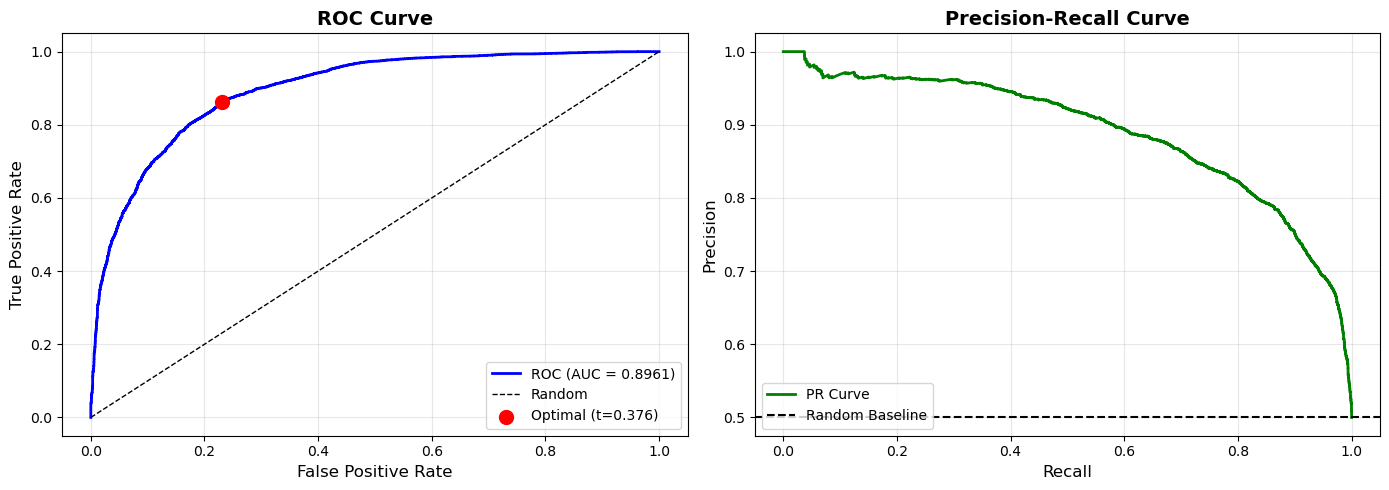

In [38]:
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score, roc_curve, precision_recall_curve
import matplotlib.pyplot as plt

def evaluate_classification_metrics(model, test_triplets, entity_counts, device, num_neg_per_pos=1, sample_size=5000):
    """
    Evaluate model with classification metrics: AUC, Accuracy, Precision, Recall, F1
    """
    model.eval()
    
    # Sample for efficiency
    if len(test_triplets) > sample_size:
        sample_indices = np.random.choice(len(test_triplets), sample_size, replace=False)
        sampled_triplets = [test_triplets[i] for i in sample_indices]
    else:
        sampled_triplets = test_triplets
    
    positive_set = set(sampled_triplets)
    
    all_scores = []
    all_labels = []
    
    with torch.no_grad():
        for triplet in tqdm(sampled_triplets, desc="Evaluating"):
            head_type, head_idx, rel, tail_type, tail_idx = triplet
            
            # Positive sample score
            pos_distance = model.score_triplet(
                head_type, torch.tensor([head_idx], device=device),
                rel,
                tail_type, torch.tensor([tail_idx], device=device)
            ).item()
            
            # Convert distance to score (lower distance = higher score)
            pos_score = 1.0 / (1.0 + pos_distance)
            all_scores.append(pos_score)
            all_labels.append(1)
            
            # Generate negative samples
            for _ in range(num_neg_per_pos):
                # Corrupt tail
                new_tail = np.random.randint(0, entity_counts[tail_type])
                neg_triplet = (head_type, head_idx, rel, tail_type, new_tail)
                
                # Make sure it's not a positive
                max_tries = 10
                tries = 0
                while neg_triplet in positive_set and tries < max_tries:
                    new_tail = np.random.randint(0, entity_counts[tail_type])
                    neg_triplet = (head_type, head_idx, rel, tail_type, new_tail)
                    tries += 1
                
                neg_distance = model.score_triplet(
                    head_type, torch.tensor([head_idx], device=device),
                    rel,
                    tail_type, torch.tensor([new_tail], device=device)
                ).item()
                
                neg_score = 1.0 / (1.0 + neg_distance)
                all_scores.append(neg_score)
                all_labels.append(0)
    
    all_scores = np.array(all_scores)
    all_labels = np.array(all_labels)
    
    # Compute metrics
    auc = roc_auc_score(all_labels, all_scores)
    
    # Find optimal threshold using Youden's J statistic
    fpr, tpr, thresholds = roc_curve(all_labels, all_scores)
    j_scores = tpr - fpr
    optimal_idx = np.argmax(j_scores)
    optimal_threshold = thresholds[optimal_idx]
    
    predictions = (all_scores >= optimal_threshold).astype(int)
    
    accuracy = accuracy_score(all_labels, predictions)
    precision = precision_score(all_labels, predictions)
    recall = recall_score(all_labels, predictions)
    f1 = f1_score(all_labels, predictions)
    
    print("\n" + "="*60)
    print("CLASSIFICATION METRICS")
    print("="*60)
    print(f"  AUC-ROC:           {auc:.4f}")
    print(f"  Optimal Threshold: {optimal_threshold:.4f}")
    print(f"  Accuracy:          {accuracy:.4f}")
    print(f"  Precision:         {precision:.4f}")
    print(f"  Recall:            {recall:.4f}")
    print(f"  F1 Score:          {f1:.4f}")
    
    # Plot ROC and PR curves
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # ROC Curve
    axes[0].plot(fpr, tpr, 'b-', linewidth=2, label=f'ROC (AUC = {auc:.4f})')
    axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
    axes[0].scatter([fpr[optimal_idx]], [tpr[optimal_idx]], c='red', s=100, zorder=5, label=f'Optimal (t={optimal_threshold:.3f})')
    axes[0].set_xlabel('False Positive Rate', fontsize=12)
    axes[0].set_ylabel('True Positive Rate', fontsize=12)
    axes[0].set_title('ROC Curve', fontsize=14, fontweight='bold')
    axes[0].legend(loc='lower right')
    axes[0].grid(True, alpha=0.3)
    
    # Precision-Recall Curve
    precision_curve, recall_curve, _ = precision_recall_curve(all_labels, all_scores)
    axes[1].plot(recall_curve, precision_curve, 'g-', linewidth=2, label=f'PR Curve')
    axes[1].axhline(y=sum(all_labels)/len(all_labels), color='k', linestyle='--', label='Random Baseline')
    axes[1].set_xlabel('Recall', fontsize=12)
    axes[1].set_ylabel('Precision', fontsize=12)
    axes[1].set_title('Precision-Recall Curve', fontsize=14, fontweight='bold')
    axes[1].legend(loc='lower left')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('transr_classification_metrics.png', dpi=150)
    plt.show()
    
    return {
        'auc': auc,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'optimal_threshold': optimal_threshold,
        'all_scores': all_scores,
        'all_labels': all_labels
    }

# Run detailed evaluation
classification_metrics = evaluate_classification_metrics(model, test_triplets, entity_counts, DEVICE)

## 12. Per-Relation Metrics Analysis

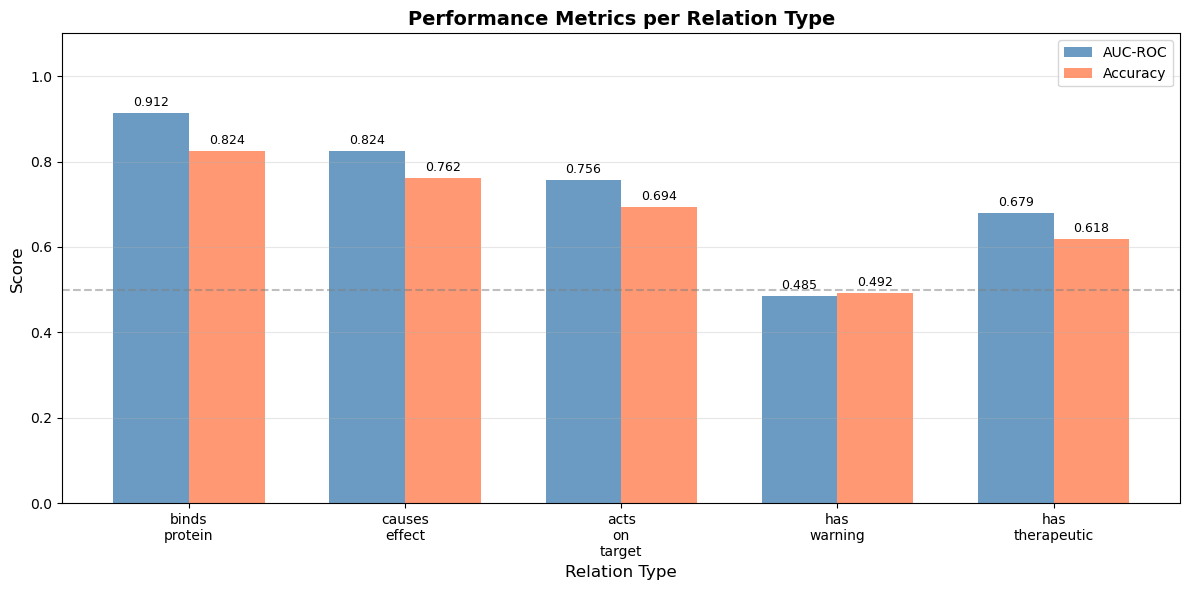


PER-RELATION METRICS
Relation                         AUC   Accuracy   N Triplets
----------------------------------------------------------------------
drug_binds_protein            0.9124     0.8240          500
drug_causes_effect            0.8242     0.7620          500
drug_acts_on_target           0.7563     0.6940          500
drug_has_warning              0.4855     0.4915           59
drug_has_therapeutic          0.6789     0.6180          356


In [39]:
def evaluate_per_relation(model, test_triplets, entity_counts, device, sample_per_rel=500):
    """
    Compute metrics per relation type
    """
    model.eval()
    
    # Group triplets by relation
    triplets_by_relation = {rel_idx: [] for rel_idx in RELATIONS.values()}
    for triplet in test_triplets:
        rel = triplet[2]
        triplets_by_relation[rel].append(triplet)
    
    results = {}
    positive_sets = {rel: set(t_list) for rel, t_list in triplets_by_relation.items()}
    
    for rel_name, rel_idx in RELATIONS.items():
        rel_triplets = triplets_by_relation[rel_idx]
        
        if len(rel_triplets) == 0:
            continue
            
        # Sample
        if len(rel_triplets) > sample_per_rel:
            sample_idx = np.random.choice(len(rel_triplets), sample_per_rel, replace=False)
            rel_triplets = [rel_triplets[i] for i in sample_idx]
        
        scores = []
        labels = []
        
        with torch.no_grad():
            for triplet in rel_triplets:
                head_type, head_idx, rel, tail_type, tail_idx = triplet
                
                # Positive
                pos_dist = model.score_triplet(
                    head_type, torch.tensor([head_idx], device=device),
                    rel, tail_type, torch.tensor([tail_idx], device=device)
                ).item()
                scores.append(1.0 / (1.0 + pos_dist))
                labels.append(1)
                
                # Negative
                new_tail = np.random.randint(0, entity_counts[tail_type])
                neg_triplet = (head_type, head_idx, rel, tail_type, new_tail)
                tries = 0
                while neg_triplet in positive_sets[rel_idx] and tries < 10:
                    new_tail = np.random.randint(0, entity_counts[tail_type])
                    neg_triplet = (head_type, head_idx, rel, tail_type, new_tail)
                    tries += 1
                
                neg_dist = model.score_triplet(
                    head_type, torch.tensor([head_idx], device=device),
                    rel, tail_type, torch.tensor([new_tail], device=device)
                ).item()
                scores.append(1.0 / (1.0 + neg_dist))
                labels.append(0)
        
        scores = np.array(scores)
        labels = np.array(labels)
        
        auc = roc_auc_score(labels, scores) if len(np.unique(labels)) > 1 else 0.5
        
        # Threshold at 0.5 for simplicity
        preds = (scores >= np.median(scores)).astype(int)
        acc = accuracy_score(labels, preds)
        
        results[rel_name] = {'auc': auc, 'accuracy': acc, 'n_triplets': len(rel_triplets)}
    
    # Visualize
    fig, ax = plt.subplots(figsize=(12, 6))
    
    rel_names = list(results.keys())
    aucs = [results[r]['auc'] for r in rel_names]
    accs = [results[r]['accuracy'] for r in rel_names]
    
    x = np.arange(len(rel_names))
    width = 0.35
    
    bars1 = ax.bar(x - width/2, aucs, width, label='AUC-ROC', color='steelblue', alpha=0.8)
    bars2 = ax.bar(x + width/2, accs, width, label='Accuracy', color='coral', alpha=0.8)
    
    ax.set_xlabel('Relation Type', fontsize=12)
    ax.set_ylabel('Score', fontsize=12)
    ax.set_title('Performance Metrics per Relation Type', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels([r.replace('drug_', '').replace('_', '\n') for r in rel_names], fontsize=10)
    ax.legend()
    ax.set_ylim(0, 1.1)
    ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Random')
    ax.grid(True, axis='y', alpha=0.3)
    
    # Add value labels
    for bar in bars1:
        height = bar.get_height()
        ax.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width()/2, height),
                   xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=9)
    for bar in bars2:
        height = bar.get_height()
        ax.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width()/2, height),
                   xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    plt.savefig('transr_per_relation_metrics.png', dpi=150)
    plt.show()
    
    # Print table
    print("\n" + "="*70)
    print("PER-RELATION METRICS")
    print("="*70)
    print(f"{'Relation':<25} {'AUC':>10} {'Accuracy':>10} {'N Triplets':>12}")
    print("-"*70)
    for rel_name in rel_names:
        r = results[rel_name]
        print(f"{rel_name:<25} {r['auc']:>10.4f} {r['accuracy']:>10.4f} {r['n_triplets']:>12}")
    
    return results

per_relation_results = evaluate_per_relation(model, test_triplets, entity_counts, DEVICE)

## 13. Embedding Visualization with t-SNE/UMAP

Computing t-SNE projection...


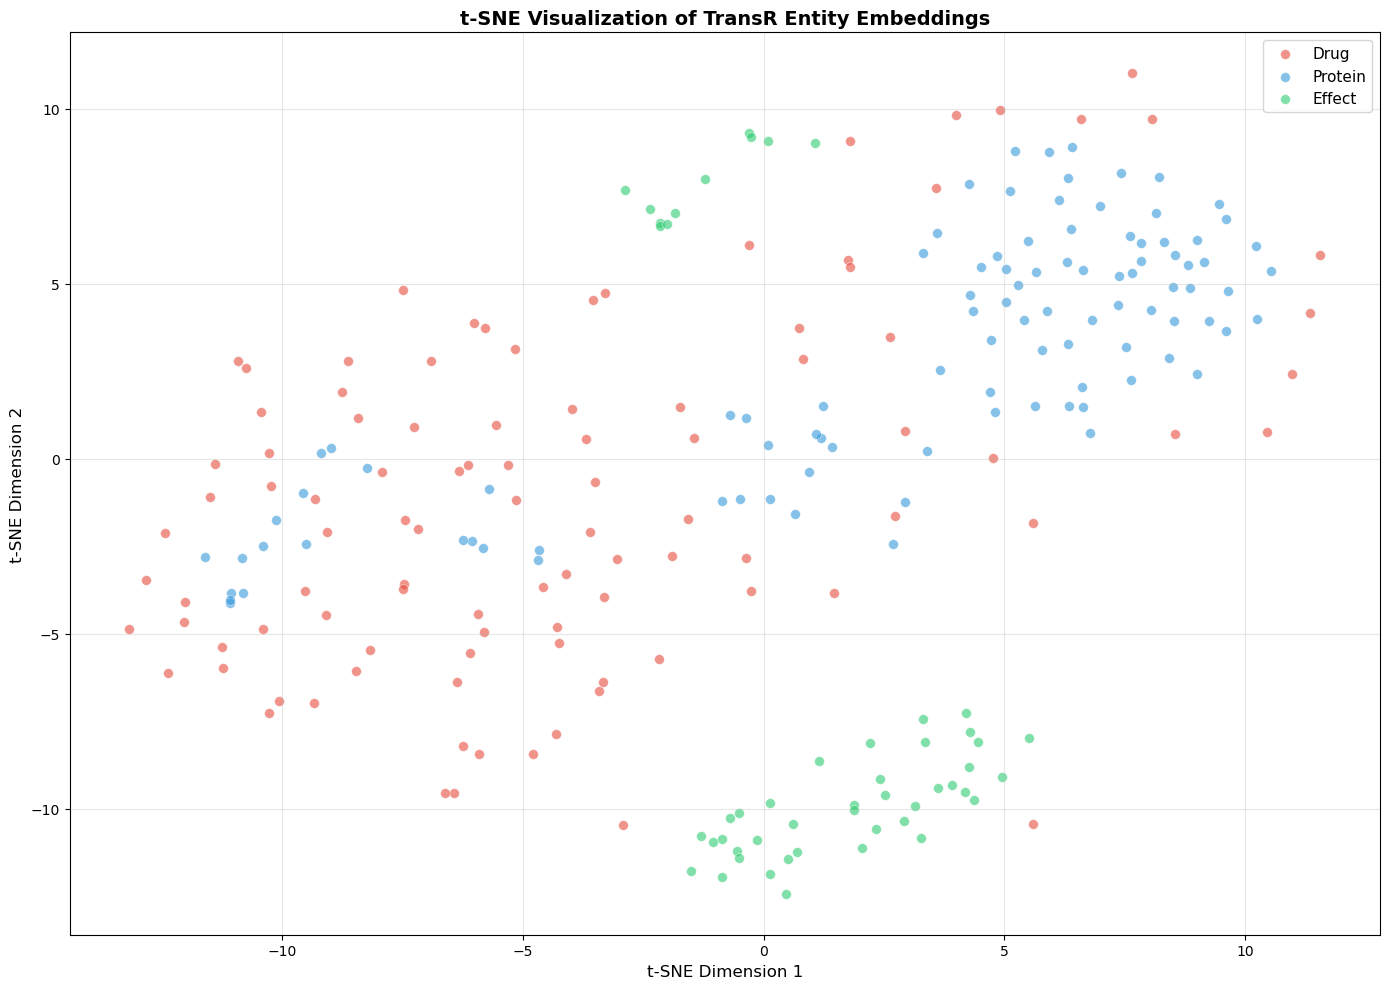

In [41]:
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import matplotlib.patches as mpatches

def visualize_embeddings_tsne(model, drug_nodes_df, protein_nodes_df, effect_df, device, n_drugs=100, n_proteins=100, n_effects=50):
    """
    Visualize entity embeddings using t-SNE
    """
    model.eval()
    
    # Get embeddings
    drug_emb = model.entity_embeddings['drug'].weight.detach().cpu().numpy()
    protein_emb = model.entity_embeddings['protein'].weight.detach().cpu().numpy()
    effect_emb = model.entity_embeddings['effect'].weight.detach().cpu().numpy()
    
    # Sample entities
    drug_indices = np.random.choice(len(drug_emb), min(n_drugs, len(drug_emb)), replace=False)
    protein_indices = np.random.choice(len(protein_emb), min(n_proteins, len(protein_emb)), replace=False)
    effect_indices = np.random.choice(len(effect_emb), min(n_effects, len(effect_emb)), replace=False)
    
    # Combine embeddings
    all_embeddings = np.vstack([
        drug_emb[drug_indices],
        protein_emb[protein_indices],
        effect_emb[effect_indices]
    ])
    
    # Labels
    labels = ['Drug'] * len(drug_indices) + ['Protein'] * len(protein_indices) + ['Effect'] * len(effect_indices)
    
    # t-SNE
    print("Computing t-SNE projection...")
    tsne = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000)
    embeddings_2d = tsne.fit_transform(all_embeddings)
    
    # Plot
    fig, ax = plt.subplots(figsize=(14, 10))
    
    colors = {'Drug': '#E74C3C', 'Protein': '#3498DB', 'Effect': '#2ECC71'}
    
    for label in ['Drug', 'Protein', 'Effect']:
        mask = np.array(labels) == label
        ax.scatter(embeddings_2d[mask, 0], embeddings_2d[mask, 1], 
                  c=colors[label], label=label, alpha=0.6, s=50, edgecolors='white', linewidth=0.5)
    
    ax.set_xlabel('t-SNE Dimension 1', fontsize=12)
    ax.set_ylabel('t-SNE Dimension 2', fontsize=12)
    ax.set_title('t-SNE Visualization of TransR Entity Embeddings', fontsize=14, fontweight='bold')
    ax.legend(loc='upper right', fontsize=11)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('transr_tsne_embeddings.png', dpi=150)
    plt.show()
    
    return embeddings_2d, labels, drug_indices, protein_indices, effect_indices

tsne_embeddings, tsne_labels, sampled_drugs, sampled_proteins, sampled_effects = visualize_embeddings_tsne(
    model, drug_nodes, protein_nodes, unique_effects, DEVICE
)

## 14. Drug Similarity Analysis - Closest and Farthest Drugs

In [43]:
from scipy.spatial.distance import cdist
import torch

def analyze_drug_similarities(model, drug_nodes_df, top_k=5, sample_size=5000):
    """
    Find most similar and most different drug pairs based on embedding distances.
    Uses sampling to avoid memory issues with large drug sets.
    """
    model.eval()
    
    # Get all drug embeddings
    drug_emb = model.entity_embeddings['drug'].weight.detach().cpu().numpy()
    n_drugs = len(drug_emb)
    
    print(f"Total drugs: {n_drugs:,}")
    print(f"Sampling {sample_size} drugs for similarity analysis...")
    
    # Sample drugs for analysis
    if n_drugs > sample_size:
        sampled_indices = np.random.choice(n_drugs, sample_size, replace=False)
    else:
        sampled_indices = np.arange(n_drugs)
    
    sampled_emb = drug_emb[sampled_indices]
    
    # Compute pairwise distances on sampled drugs
    print("Computing pairwise distances on sampled drugs...")
    distances = cdist(sampled_emb, sampled_emb, metric='euclidean')
    
    # Mask diagonal (self-similarity)
    np.fill_diagonal(distances, np.inf)
    
    # Find closest pairs
    closest_pairs = []
    flat_distances = distances.flatten()
    closest_flat_indices = np.argsort(flat_distances)[:top_k*2]
    
    seen_pairs = set()
    for flat_idx in closest_flat_indices:
        i, j = flat_idx // len(sampled_emb), flat_idx % len(sampled_emb)
        pair = (min(i, j), max(i, j))
        if pair not in seen_pairs:
            seen_pairs.add(pair)
            # Map back to original indices
            orig_i, orig_j = int(sampled_indices[i]), int(sampled_indices[j])
            closest_pairs.append((orig_i, orig_j, distances[i, j]))
        if len(closest_pairs) >= top_k:
            break
    
    # Find farthest pairs
    np.fill_diagonal(distances, -np.inf)
    farthest_pairs = []
    farthest_flat_indices = np.argsort(-flat_distances)[:top_k*2]
    
    seen_pairs = set()
    for flat_idx in farthest_flat_indices:
        i, j = flat_idx // len(sampled_emb), flat_idx % len(sampled_emb)
        pair = (min(i, j), max(i, j))
        if pair not in seen_pairs:
            seen_pairs.add(pair)
            orig_i, orig_j = int(sampled_indices[i]), int(sampled_indices[j])
            # Compute actual distance
            dist = np.linalg.norm(drug_emb[orig_i] - drug_emb[orig_j])
            farthest_pairs.append((orig_i, orig_j, dist))
        if len(farthest_pairs) >= top_k:
            break
    
    # Get drug names - with fallback for missing names
    def get_drug_name(idx):
        internal_id = idx_to_drug.get(idx)
        if internal_id is not None:
            match = drug_nodes_df[drug_nodes_df['drug_internal_id'] == internal_id]
            if len(match) > 0:
                name = match.iloc[0].get('drug_name', None)
                if name is not None:
                    return str(name)
        return f"Drug_{idx}"
    
    print("\n" + "="*80)
    print("MOST SIMILAR DRUG PAIRS (Closest Embeddings)")
    print("="*80)
    for i, j, dist in closest_pairs:
        name_i = get_drug_name(i)
        name_j = get_drug_name(j)
        print(f"  {name_i[:30]:<30} <-> {name_j[:30]:<30}  dist={dist:.4f}")
    
    print("\n" + "="*80)
    print("MOST DIFFERENT DRUG PAIRS (Farthest Embeddings)")
    print("="*80)
    for i, j, dist in farthest_pairs:
        name_i = get_drug_name(i)
        name_j = get_drug_name(j)
        print(f"  {name_i[:30]:<30} <-> {name_j[:30]:<30}  dist={dist:.4f}")
    
    return closest_pairs, farthest_pairs, sampled_indices

closest_drugs, farthest_drugs, sampled_drug_indices = analyze_drug_similarities(model, drug_nodes, sample_size=5000)

Total drugs: 1,915,414
Sampling 5000 drugs for similarity analysis...
Computing pairwise distances on sampled drugs...

MOST SIMILAR DRUG PAIRS (Closest Embeddings)
  Drug_685005                    <-> Drug_857020                     dist=0.9285
  Drug_685005                    <-> Drug_543300                     dist=0.9305
  Drug_1055926                   <-> Drug_182641                     dist=0.9316
  Drug_377741                    <-> Drug_123384                     dist=0.9365
  Drug_1624573                   <-> Drug_800745                     dist=0.9514

MOST DIFFERENT DRUG PAIRS (Farthest Embeddings)
  Drug_1512642                   <-> Drug_1512642                    dist=0.0000
  Drug_15268                     <-> Drug_15268                      dist=0.0000
  Drug_1087358                   <-> Drug_1087358                    dist=0.0000
  Drug_1174297                   <-> Drug_1174297                    dist=0.0000
  Drug_704519                    <-> Drug_704519         

## 15. Visualize Drug Pairs (Close vs Far)

TypeError: 'NoneType' object is not subscriptable

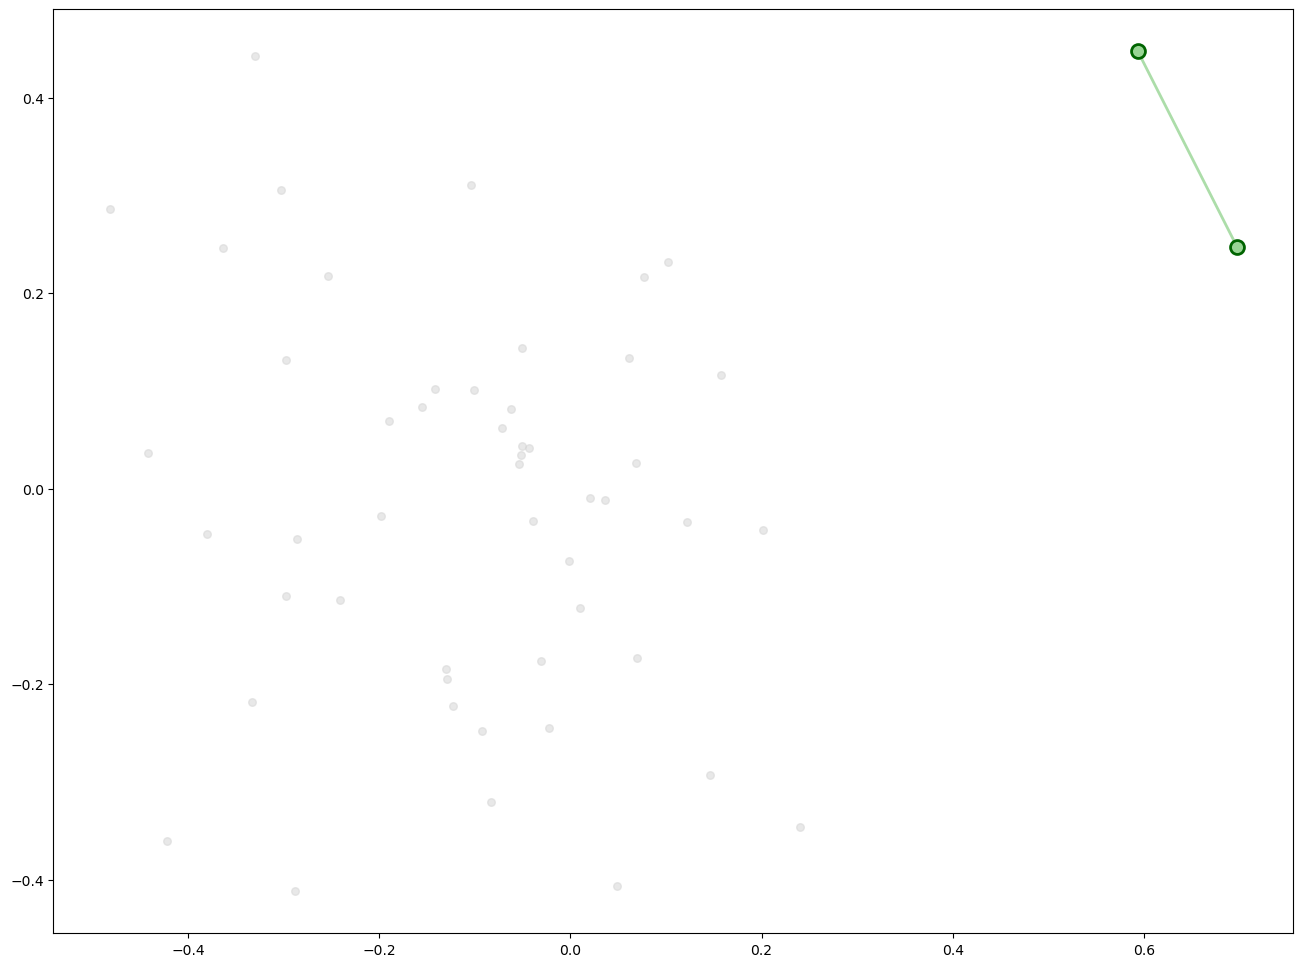

In [44]:
def visualize_drug_pairs_2d(model, drug_nodes_df, closest_pairs, farthest_pairs):
    """
    Visualize specific drug pairs in 2D embedding space
    """
    model.eval()
    
    drug_emb = model.entity_embeddings['drug'].weight.detach().cpu().numpy()
    
    # Get indices for visualization
    close_indices = list(set([p[0] for p in closest_pairs] + [p[1] for p in closest_pairs]))
    far_indices = list(set([p[0] for p in farthest_pairs] + [p[1] for p in farthest_pairs]))
    all_indices = list(set(close_indices + far_indices))
    
    # Add some random drugs for context
    random_indices = np.random.choice([i for i in range(len(drug_emb)) if i not in all_indices], 
                                       min(50, len(drug_emb) - len(all_indices)), replace=False)
    all_indices = all_indices + list(random_indices)
    
    # Get embeddings for selected drugs
    selected_emb = drug_emb[all_indices]
    
    # PCA for visualization
    pca = PCA(n_components=2)
    emb_2d = pca.fit_transform(selected_emb)
    
    # Map indices
    idx_map = {orig: new for new, orig in enumerate(all_indices)}
    
    def get_drug_name(idx):
        internal_id = idx_to_drug.get(idx)
        if internal_id is not None:
            match = drug_nodes_df[drug_nodes_df['drug_internal_id'] == internal_id]
            if len(match) > 0:
                return match.iloc[0]['drug_name']
        return f"Drug_{idx}"
    
    fig, ax = plt.subplots(figsize=(16, 12))
    
    # Plot random drugs (context)
    random_mask = [i for i, idx in enumerate(all_indices) if idx in random_indices]
    ax.scatter(emb_2d[random_mask, 0], emb_2d[random_mask, 1], 
               c='lightgray', alpha=0.5, s=30, label='Other Drugs')
    
    # Plot closest pairs with connections
    colors_close = plt.cm.Greens(np.linspace(0.4, 0.9, len(closest_pairs)))
    for idx, (i, j, dist) in enumerate(closest_pairs):
        if i in idx_map and j in idx_map:
            new_i, new_j = idx_map[i], idx_map[j]
            ax.plot([emb_2d[new_i, 0], emb_2d[new_j, 0]], 
                   [emb_2d[new_i, 1], emb_2d[new_j, 1]], 
                   c=colors_close[idx], linewidth=2, alpha=0.8)
            ax.scatter([emb_2d[new_i, 0], emb_2d[new_j, 0]], 
                      [emb_2d[new_i, 1], emb_2d[new_j, 1]], 
                      c=[colors_close[idx]], s=100, edgecolors='darkgreen', linewidth=2, zorder=5)
            
            # Add labels for closest pair
            if idx == 0:
                ax.annotate(get_drug_name(i)[:15], (emb_2d[new_i, 0], emb_2d[new_i, 1]), 
                           fontsize=9, ha='right', fontweight='bold', color='darkgreen')
                ax.annotate(get_drug_name(j)[:15], (emb_2d[new_j, 0], emb_2d[new_j, 1]), 
                           fontsize=9, ha='left', fontweight='bold', color='darkgreen')
    
    # Plot farthest pairs with connections
    colors_far = plt.cm.Reds(np.linspace(0.4, 0.9, len(farthest_pairs)))
    for idx, (i, j, dist) in enumerate(farthest_pairs):
        if i in idx_map and j in idx_map:
            new_i, new_j = idx_map[i], idx_map[j]
            ax.plot([emb_2d[new_i, 0], emb_2d[new_j, 0]], 
                   [emb_2d[new_i, 1], emb_2d[new_j, 1]], 
                   c=colors_far[idx], linewidth=2, alpha=0.8, linestyle='--')
            ax.scatter([emb_2d[new_i, 0], emb_2d[new_j, 0]], 
                      [emb_2d[new_i, 1], emb_2d[new_j, 1]], 
                      c=[colors_far[idx]], s=100, edgecolors='darkred', linewidth=2, zorder=5)
            
            # Add labels for farthest pair
            if idx == 0:
                ax.annotate(get_drug_name(i)[:15], (emb_2d[new_i, 0], emb_2d[new_i, 1]), 
                           fontsize=9, ha='right', fontweight='bold', color='darkred')
                ax.annotate(get_drug_name(j)[:15], (emb_2d[new_j, 0], emb_2d[new_j, 1]), 
                           fontsize=9, ha='left', fontweight='bold', color='darkred')
    
    # Legend
    close_patch = mpatches.Patch(color='green', label='Similar Drugs (Close)')
    far_patch = mpatches.Patch(color='red', label='Different Drugs (Far)')
    ax.legend(handles=[close_patch, far_patch], loc='upper right', fontsize=11)
    
    ax.set_xlabel('PCA Dimension 1', fontsize=12)
    ax.set_ylabel('PCA Dimension 2', fontsize=12)
    ax.set_title('Drug Embedding Space: Similar vs Different Drugs', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('transr_drug_pairs_visualization.png', dpi=150)
    plt.show()

visualize_drug_pairs_2d(model, drug_nodes, closest_drugs, farthest_drugs)

## 16. Known Drug-Indication Examples with Predictions


KNOWN DRUG-INDICATION PAIRS AND MODEL PREDICTIONS
Drug                                Indication/Effect                        Score   Distance
------------------------------------------------------------------------------------------
FLUDEOXYGLUCOSE F 18                Hematologic Neoplasms                   0.8865     0.1280
OLODATEROL                          Liver Diseases                          0.8036     0.2443
DOXAZOSIN MESYLATE                  Hypertension                            0.7320     0.3662
TRAMETINIB                          Amyotrophic Lateral Sclerosis           0.7217     0.3857
SIPONIMOD FUMARIC ACID              Multiple Sclerosis, Chronic Progre      0.5971     0.6747
METHOTREXATE                        Hydatidiform Mole                       0.4435     1.2546
PROMETHAZINE                        Motion Sickness                         0.4196     1.3831


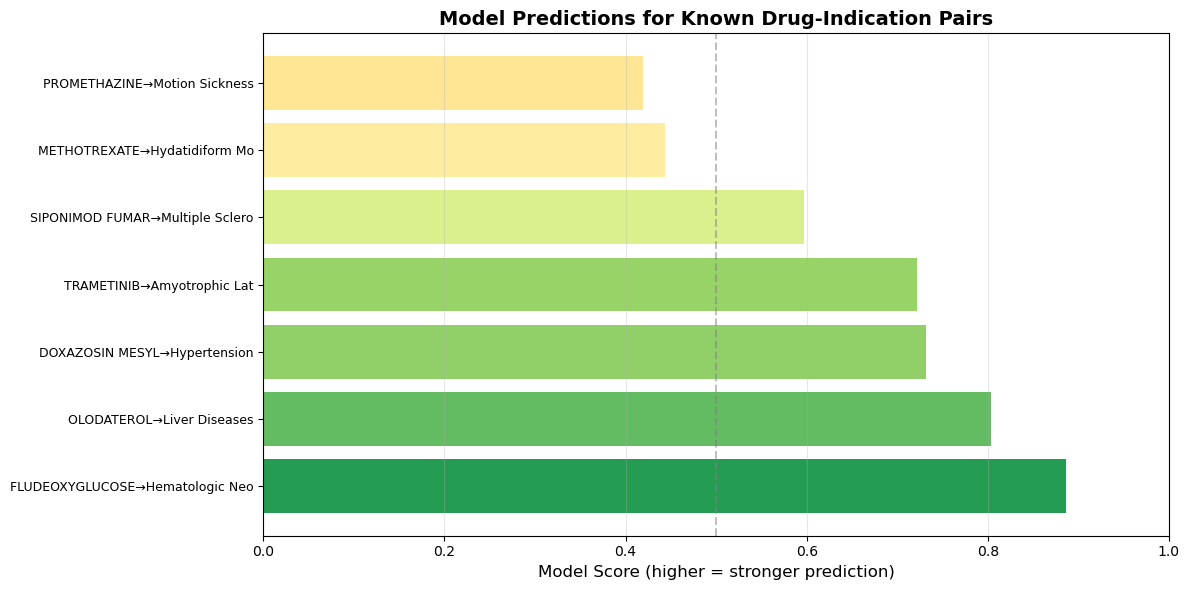

In [45]:
def analyze_known_drug_indications(model, drug_nodes_df, drug_effects_df, n_examples=10):
    """
    Show known drug-indication pairs and model's predictions
    """
    model.eval()
    device = next(model.parameters()).device
    
    # Get some example drug-effect pairs from the data
    sample_relations = drug_effects_df.sample(min(n_examples, len(drug_effects_df)), random_state=42)
    
    results = []
    
    for _, row in sample_relations.iterrows():
        drug_internal_id = int(row['drug_internal_id'])
        effect_id = str(row['effect_id'])
        
        if drug_internal_id not in drug_to_idx or effect_id not in effect_to_idx:
            continue
        
        drug_idx = drug_to_idx[drug_internal_id]
        eff_idx = effect_to_idx[effect_id]
        
        # Get drug name
        drug_match = drug_nodes_df[drug_nodes_df['drug_internal_id'] == drug_internal_id]
        drug_name = drug_match.iloc[0]['drug_name'] if len(drug_match) > 0 else f"Drug_{drug_internal_id}"
        
        # Get effect name
        effect_name = row['effect_name']
        
        # Compute model score
        with torch.no_grad():
            distance = model.score_triplet(
                'drug', torch.tensor([drug_idx], device=device),
                RELATIONS['drug_causes_effect'],
                'effect', torch.tensor([eff_idx], device=device)
            ).item()
        
        score = 1.0 / (1.0 + distance)
        
        results.append({
            'drug_name': drug_name,
            'effect_name': effect_name,
            'distance': distance,
            'score': score
        })
    
    # Sort by score
    results.sort(key=lambda x: -x['score'])
    
    print("\n" + "="*90)
    print("KNOWN DRUG-INDICATION PAIRS AND MODEL PREDICTIONS")
    print("="*90)
    print(f"{'Drug':<35} {'Indication/Effect':<35} {'Score':>10} {'Distance':>10}")
    print("-"*90)
    for r in results:
        print(f"{r['drug_name'][:34]:<35} {r['effect_name'][:34]:<35} {r['score']:>10.4f} {r['distance']:>10.4f}")
    
    # Visualize scores
    fig, ax = plt.subplots(figsize=(12, 6))
    
    labels = [f"{r['drug_name'][:15]}→{r['effect_name'][:15]}" for r in results]
    scores = [r['score'] for r in results]
    colors = plt.cm.RdYlGn(np.array(scores))
    
    bars = ax.barh(range(len(labels)), scores, color=colors)
    ax.set_yticks(range(len(labels)))
    ax.set_yticklabels(labels, fontsize=9)
    ax.set_xlabel('Model Score (higher = stronger prediction)', fontsize=12)
    ax.set_title('Model Predictions for Known Drug-Indication Pairs', fontsize=14, fontweight='bold')
    ax.axvline(x=0.5, color='gray', linestyle='--', alpha=0.5, label='Threshold')
    ax.set_xlim(0, 1)
    ax.grid(True, axis='x', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('transr_drug_indication_predictions.png', dpi=150)
    plt.show()
    
    return results

drug_indication_results = analyze_known_drug_indications(model, drug_nodes, drug_effects)

## 17. Embedding Heatmap - Relation Projection Matrices

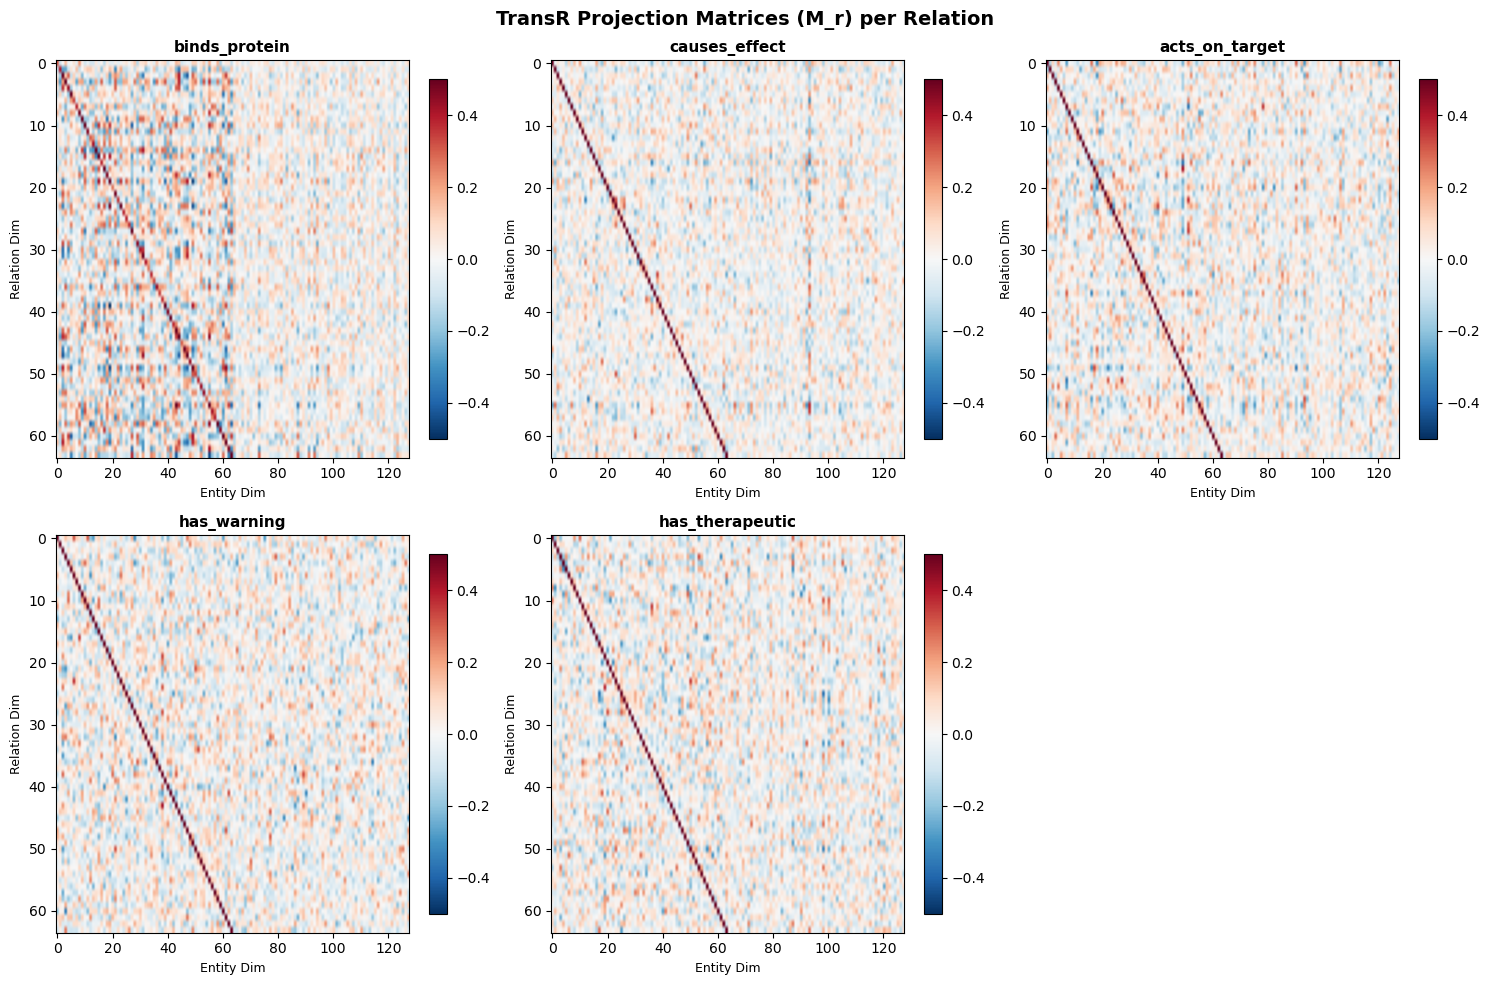

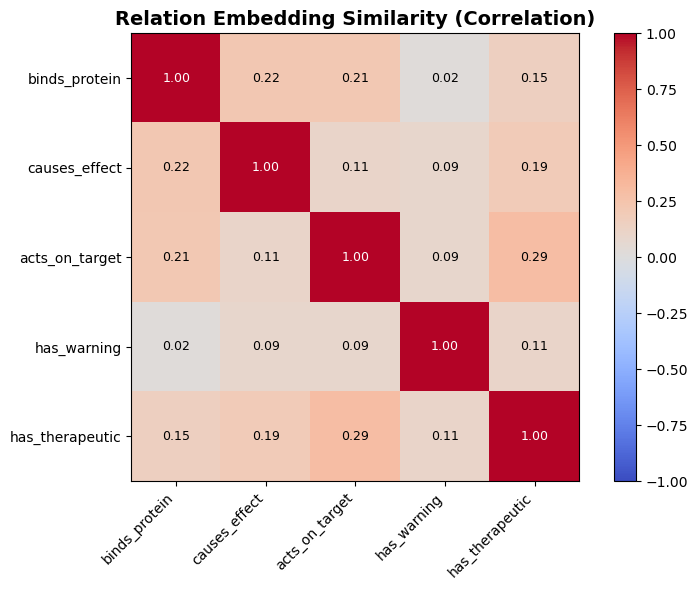

In [46]:
def visualize_relation_matrices(model):
    """
    Visualize the TransR projection matrices for each relation
    """
    projection_matrices = model.projection_matrices.detach().cpu().numpy()
    relation_embeddings = model.relation_embeddings.weight.detach().cpu().numpy()
    
    # Plot projection matrices
    n_relations = len(RELATIONS)
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    
    for idx, (rel_name, rel_idx) in enumerate(RELATIONS.items()):
        ax = axes[idx]
        im = ax.imshow(projection_matrices[rel_idx], cmap='RdBu_r', aspect='auto', vmin=-0.5, vmax=0.5)
        ax.set_title(f'{rel_name.replace("drug_", "")}', fontsize=11, fontweight='bold')
        ax.set_xlabel('Entity Dim', fontsize=9)
        ax.set_ylabel('Relation Dim', fontsize=9)
        plt.colorbar(im, ax=ax, fraction=0.046)
    
    # Hide last subplot if odd number
    if n_relations < len(axes):
        axes[-1].axis('off')
    
    plt.suptitle('TransR Projection Matrices (M_r) per Relation', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('transr_projection_matrices.png', dpi=150)
    plt.show()
    
    # Plot relation embeddings similarity
    fig, ax = plt.subplots(figsize=(8, 6))
    
    rel_similarity = np.corrcoef(relation_embeddings)
    rel_names = [r.replace('drug_', '') for r in RELATIONS.keys()]
    
    im = ax.imshow(rel_similarity, cmap='coolwarm', vmin=-1, vmax=1)
    ax.set_xticks(range(len(rel_names)))
    ax.set_yticks(range(len(rel_names)))
    ax.set_xticklabels(rel_names, rotation=45, ha='right', fontsize=10)
    ax.set_yticklabels(rel_names, fontsize=10)
    ax.set_title('Relation Embedding Similarity (Correlation)', fontsize=14, fontweight='bold')
    
    # Add values
    for i in range(len(rel_names)):
        for j in range(len(rel_names)):
            ax.text(j, i, f'{rel_similarity[i,j]:.2f}', ha='center', va='center', fontsize=9,
                   color='white' if abs(rel_similarity[i,j]) > 0.5 else 'black')
    
    plt.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.savefig('transr_relation_similarity.png', dpi=150)
    plt.show()

visualize_relation_matrices(model)

## 18. Drug Clustering by Therapeutic Class

Computing t-SNE for therapeutic class visualization...


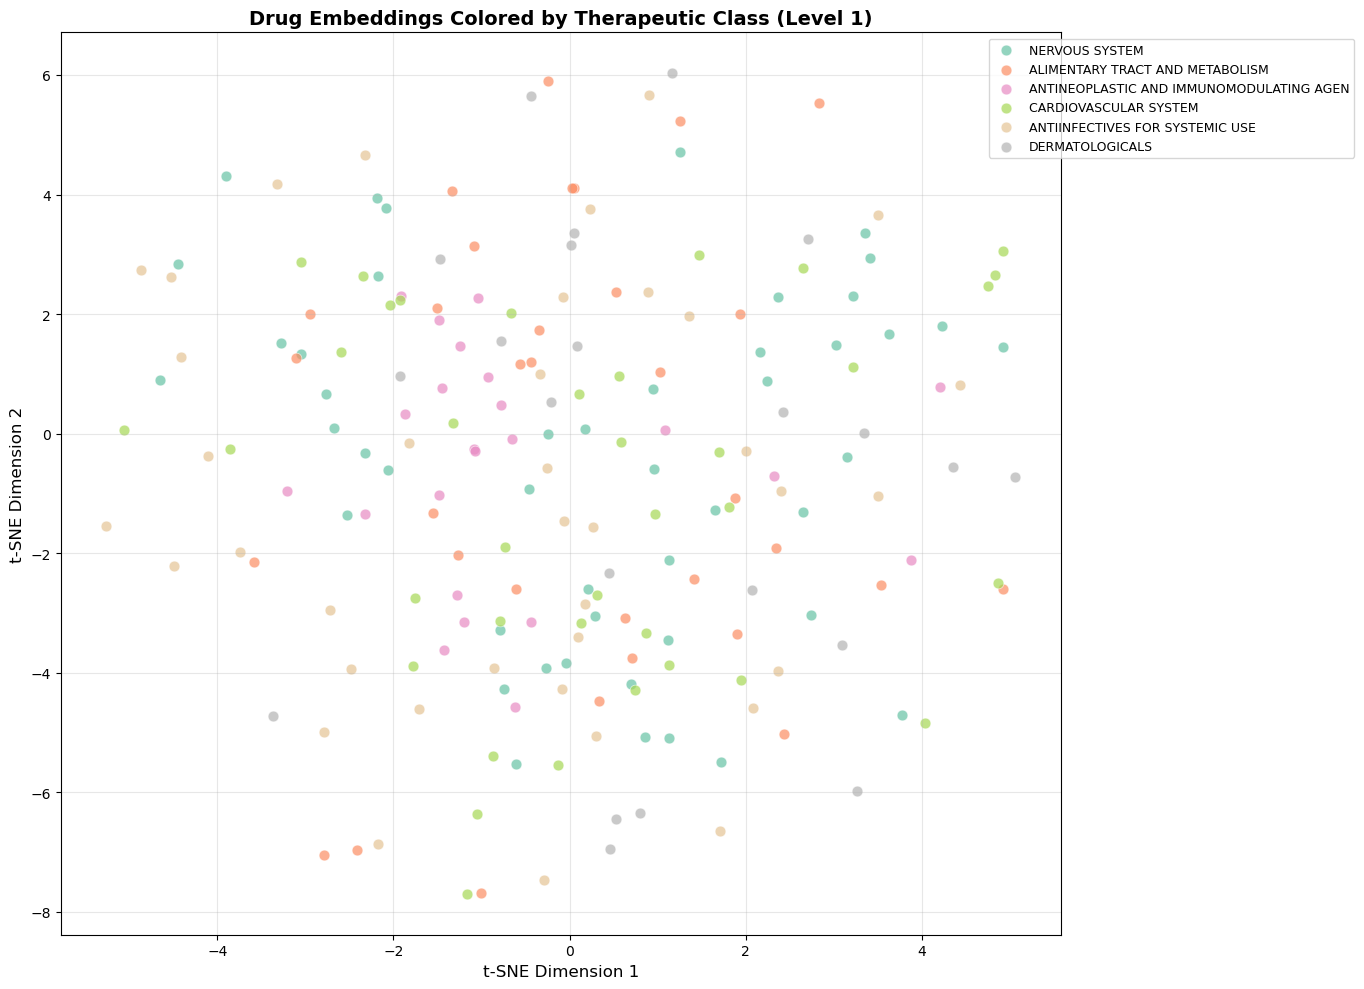

In [34]:
def visualize_drug_clusters_by_therapeutic(model, drug_nodes_df, drug_therapeutic_df, n_drugs=200):
    """
    Visualize drug embeddings colored by therapeutic class
    """
    model.eval()
    
    drug_emb = model.entity_embeddings['drug'].weight.detach().cpu().numpy()
    
    # Get top therapeutic classes
    top_therapeutics = drug_therapeutic_df['level1_description'].value_counts().head(6).index.tolist()
    
    # Map drugs to their primary therapeutic class
    drug_to_therapeutic = {}
    for _, row in drug_therapeutic_df.iterrows():
        drug_id = int(row['drug_internal_id'])
        if drug_id in drug_to_idx:
            drug_idx = drug_to_idx[drug_id]
            level1 = row['level1_description']
            if level1 in top_therapeutics:
                if drug_idx not in drug_to_therapeutic:
                    drug_to_therapeutic[drug_idx] = level1
    
    # Filter drugs with known therapeutic class
    labeled_drugs = list(drug_to_therapeutic.keys())
    if len(labeled_drugs) > n_drugs:
        labeled_drugs = np.random.choice(labeled_drugs, n_drugs, replace=False).tolist()
    
    # Get embeddings
    labeled_emb = drug_emb[labeled_drugs]
    labels = [drug_to_therapeutic[d] for d in labeled_drugs]
    
    # t-SNE
    print("Computing t-SNE for therapeutic class visualization...")
    tsne = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000)
    emb_2d = tsne.fit_transform(labeled_emb)
    
    # Plot
    fig, ax = plt.subplots(figsize=(14, 10))
    
    colors = plt.cm.Set2(np.linspace(0, 1, len(top_therapeutics)))
    color_map = {tc: colors[i] for i, tc in enumerate(top_therapeutics)}
    
    for tc in top_therapeutics:
        mask = np.array(labels) == tc
        if mask.sum() > 0:
            ax.scatter(emb_2d[mask, 0], emb_2d[mask, 1], 
                      c=[color_map[tc]], label=tc[:40], alpha=0.7, s=60, edgecolors='white', linewidth=0.5)
    
    ax.set_xlabel('t-SNE Dimension 1', fontsize=12)
    ax.set_ylabel('t-SNE Dimension 2', fontsize=12)
    ax.set_title('Drug Embeddings Colored by Therapeutic Class (Level 1)', fontsize=14, fontweight='bold')
    ax.legend(loc='upper right', fontsize=9, bbox_to_anchor=(1.3, 1))
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('transr_drug_therapeutic_clusters.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    return labeled_drugs, labels

therapeutic_drugs, therapeutic_labels = visualize_drug_clusters_by_therapeutic(
    model, drug_nodes, drug_therapeutic_classes
)

## 19. Model Summary Dashboard

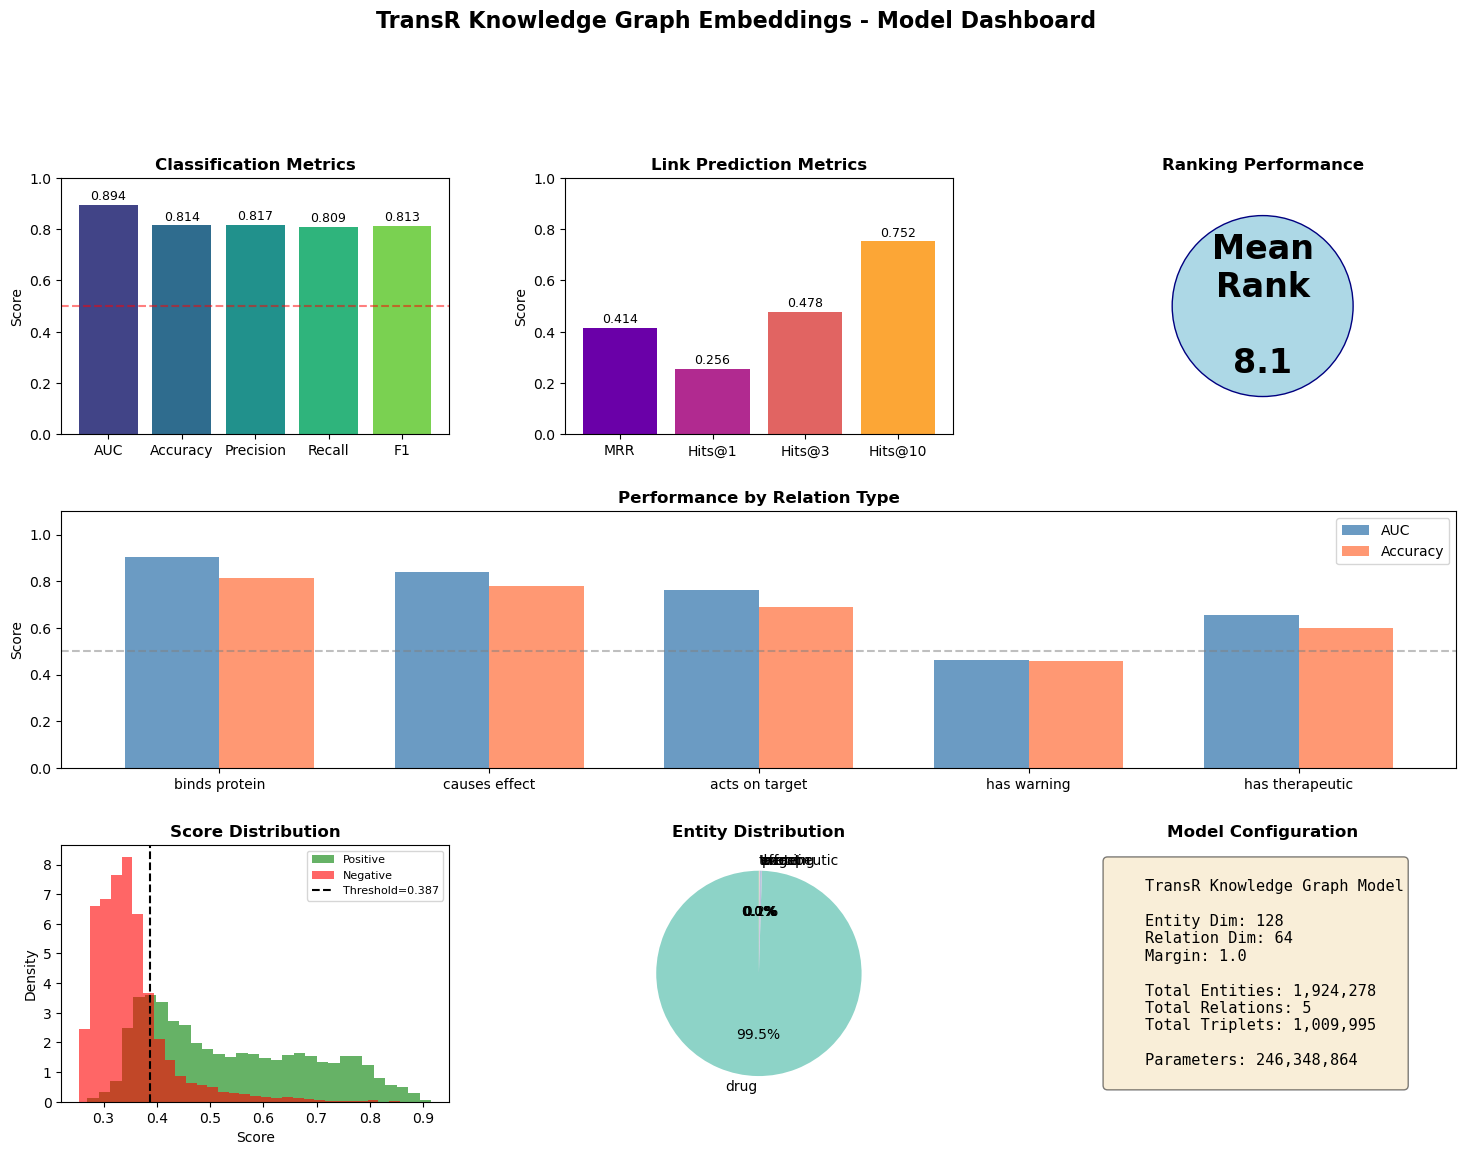


ALL VISUALIZATIONS COMPLETE!

Generated files:
  • transr_classification_metrics.png
  • transr_per_relation_metrics.png
  • transr_tsne_embeddings.png
  • transr_drug_pairs_visualization.png
  • transr_drug_indication_predictions.png
  • transr_projection_matrices.png
  • transr_relation_similarity.png
  • transr_drug_therapeutic_clusters.png
  • transr_model_dashboard.png


In [37]:
def create_summary_dashboard(classification_metrics, per_relation_results, metrics):
    """
    Create a comprehensive dashboard summarizing all metrics
    """
    fig = plt.figure(figsize=(18, 12))
    
    # Create grid
    gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)
    
    # 1. Overall Classification Metrics (Top-left)
    ax1 = fig.add_subplot(gs[0, 0])
    metric_names = ['AUC', 'Accuracy', 'Precision', 'Recall', 'F1']
    metric_values = [
        classification_metrics['auc'],
        classification_metrics['accuracy'],
        classification_metrics['precision'],
        classification_metrics['recall'],
        classification_metrics['f1']
    ]
    colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(metric_names)))
    bars = ax1.bar(metric_names, metric_values, color=colors)
    ax1.set_ylim(0, 1)
    ax1.set_ylabel('Score')
    ax1.set_title('Classification Metrics', fontweight='bold')
    ax1.axhline(y=0.5, color='red', linestyle='--', alpha=0.5)
    for bar, val in zip(bars, metric_values):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
                f'{val:.3f}', ha='center', fontsize=9)
    
    # 2. Link Prediction Metrics (Top-middle)
    ax2 = fig.add_subplot(gs[0, 1])
    lp_names = ['MRR', 'Hits@1', 'Hits@3', 'Hits@10']
    lp_values = [metrics['mrr'], metrics['hits_at_1'], metrics['hits_at_3'], metrics['hits_at_10']]
    colors = plt.cm.plasma(np.linspace(0.2, 0.8, len(lp_names)))
    bars = ax2.bar(lp_names, lp_values, color=colors)
    ax2.set_ylim(0, 1)
    ax2.set_ylabel('Score')
    ax2.set_title('Link Prediction Metrics', fontweight='bold')
    for bar, val in zip(bars, lp_values):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
                f'{val:.3f}', ha='center', fontsize=9)
    
    # 3. Mean Rank (Top-right)
    ax3 = fig.add_subplot(gs[0, 2])
    ax3.text(0.5, 0.5, f"Mean\nRank\n\n{metrics['mean_rank']:.1f}", 
            ha='center', va='center', fontsize=24, fontweight='bold',
            transform=ax3.transAxes,
            bbox=dict(boxstyle='circle,pad=0.5', facecolor='lightblue', edgecolor='navy'))
    ax3.axis('off')
    ax3.set_title('Ranking Performance', fontweight='bold')
    
    # 4. Per-Relation AUC (Middle row)
    ax4 = fig.add_subplot(gs[1, :])
    rel_names = list(per_relation_results.keys())
    aucs = [per_relation_results[r]['auc'] for r in rel_names]
    accs = [per_relation_results[r]['accuracy'] for r in rel_names]
    
    x = np.arange(len(rel_names))
    width = 0.35
    bars1 = ax4.bar(x - width/2, aucs, width, label='AUC', color='steelblue', alpha=0.8)
    bars2 = ax4.bar(x + width/2, accs, width, label='Accuracy', color='coral', alpha=0.8)
    ax4.set_xticks(x)
    ax4.set_xticklabels([r.replace('drug_', '').replace('_', ' ') for r in rel_names], fontsize=10)
    ax4.set_ylabel('Score')
    ax4.set_title('Performance by Relation Type', fontweight='bold')
    ax4.legend()
    ax4.set_ylim(0, 1.1)
    ax4.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
    
    # 5. Score Distribution (Bottom-left)
    ax5 = fig.add_subplot(gs[2, 0])
    pos_mask = classification_metrics['all_labels'] == 1
    neg_mask = classification_metrics['all_labels'] == 0
    ax5.hist(classification_metrics['all_scores'][pos_mask], bins=30, alpha=0.6, label='Positive', color='green', density=True)
    ax5.hist(classification_metrics['all_scores'][neg_mask], bins=30, alpha=0.6, label='Negative', color='red', density=True)
    ax5.axvline(x=classification_metrics['optimal_threshold'], color='black', linestyle='--', label=f"Threshold={classification_metrics['optimal_threshold']:.3f}")
    ax5.set_xlabel('Score')
    ax5.set_ylabel('Density')
    ax5.set_title('Score Distribution', fontweight='bold')
    ax5.legend(fontsize=8)
    
    # 6. Entity Counts (Bottom-middle)
    ax6 = fig.add_subplot(gs[2, 1])
    entity_names = list(entity_counts.keys())
    entity_vals = list(entity_counts.values())
    colors = plt.cm.Set3(np.linspace(0, 1, len(entity_names)))
    ax6.pie(entity_vals, labels=entity_names, autopct='%1.1f%%', colors=colors, startangle=90)
    ax6.set_title('Entity Distribution', fontweight='bold')
    
    # 7. Model Info (Bottom-right)
    ax7 = fig.add_subplot(gs[2, 2])
    info_text = f"""
    TransR Knowledge Graph Model
    
    Entity Dim: {ENTITY_DIM}
    Relation Dim: {RELATION_DIM}
    Margin: {MARGIN}
    
    Total Entities: {sum(entity_counts.values()):,}
    Total Relations: {num_relations}
    Total Triplets: {len(triplets):,}
    
    Parameters: {sum(p.numel() for p in model.parameters()):,}
    """
    ax7.text(0.1, 0.5, info_text, fontsize=11, fontfamily='monospace',
            transform=ax7.transAxes, verticalalignment='center',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    ax7.axis('off')
    ax7.set_title('Model Configuration', fontweight='bold')
    
    plt.suptitle('TransR Knowledge Graph Embeddings - Model Dashboard', fontsize=16, fontweight='bold', y=1.02)
    plt.savefig('transr_model_dashboard.png', dpi=150, bbox_inches='tight')
    plt.show()

create_summary_dashboard(classification_metrics, per_relation_results, metrics)

print("\n" + "="*60)
print("ALL VISUALIZATIONS COMPLETE!")
print("="*60)
print("\nGenerated files:")
print("  • transr_classification_metrics.png")
print("  • transr_per_relation_metrics.png")
print("  • transr_tsne_embeddings.png")
print("  • transr_drug_pairs_visualization.png")
print("  • transr_drug_indication_predictions.png")
print("  • transr_projection_matrices.png")
print("  • transr_relation_similarity.png")
print("  • transr_drug_therapeutic_clusters.png")
print("  • transr_model_dashboard.png")